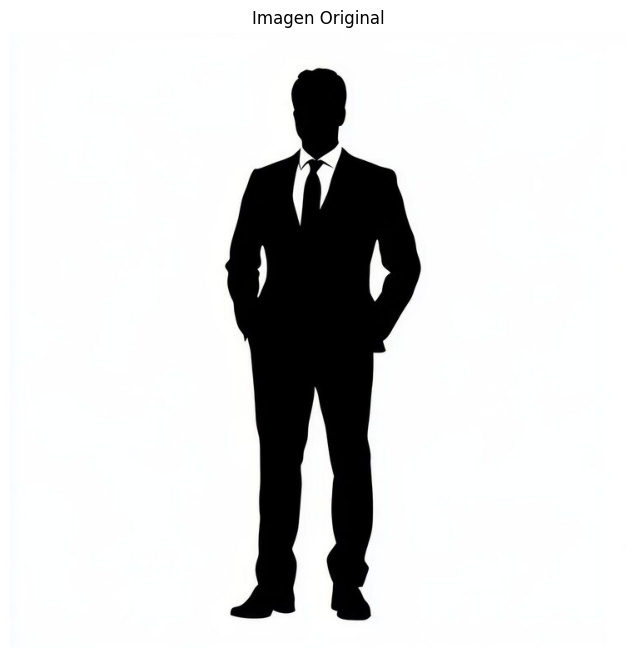

In [37]:
# ============================================================
# INSTALACIÓN DE DEPENDENCIAS
# ============================================================
# Ejecutar en terminal si es necesario:
# pip install opencv-python opencv-contrib-python numpy matplotlib

# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================
# CARGA DE IMAGEN
# ============================================================

# Cambia la ruta por tu imagen
image_path = "imagen.jpg"

# Cargar imagen
image = cv2.imread(image_path)

# Verificar carga
if image is None:
    raise Exception("No se pudo cargar la imagen")

# Convertir a RGB para matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convertir a escala de grises
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Mostrar imagen original
plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.title("Imagen Original")
plt.axis("off")
plt.show()


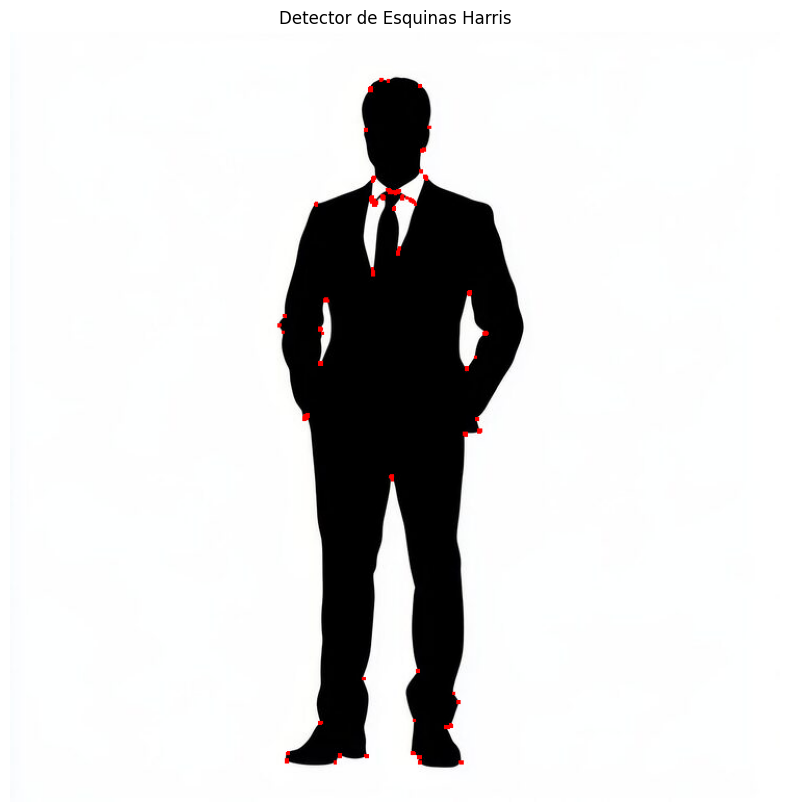

Parámetros Harris:
blockSize = 2
ksize = 0
k = 0.01


In [38]:

# ============================================================
# 1. DETECCIÓN DE ESQUINAS - HARRIS CORNER DETECTOR
# ============================================================

# Parámetros Harris
blockSize = 2
ksize = 0
k = 0.01

# Convertir a float32
gray_float = np.float32(gray)

# Aplicar detector Harris
harris = cv2.cornerHarris(gray_float, blockSize, ksize, k)

# Dilatar resultados para visualizar mejor
harris = cv2.dilate(harris, None)

# Copia de imagen para dibujar
harris_image = image_rgb.copy()

# Marcar esquinas en rojo
harris_image[harris > 0.01 * harris.max()] = [255, 0, 0]

# Mostrar resultados
plt.figure(figsize=(10,10))
plt.imshow(harris_image)
plt.title("Detector de Esquinas Harris")
plt.axis("off")
plt.show()

print("Parámetros Harris:")
print(f"blockSize = {blockSize}")
print(f"ksize = {ksize}")
print(f"k = {k}")



IMPLEMENTACIÓN SIFT
Cantidad de keypoints SIFT: 133
Tiempo de ejecución: 0.0869 segundos


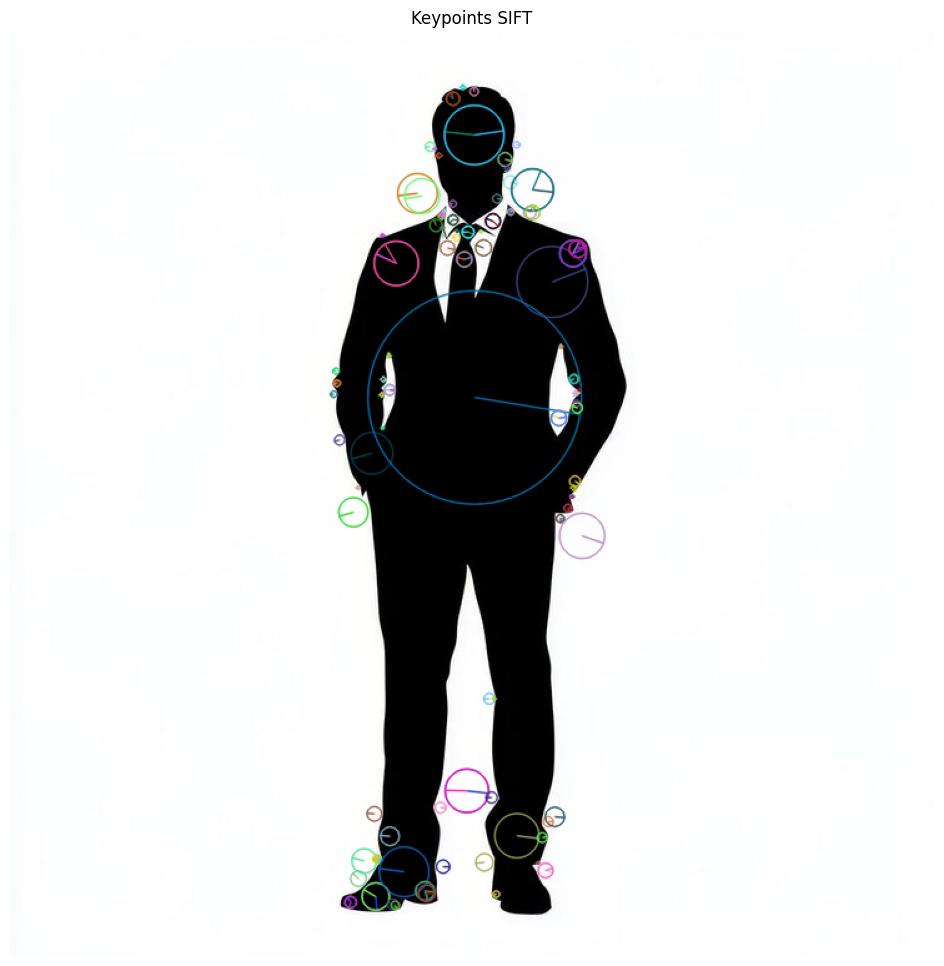

In [39]:

# ============================================================
# 2. IMPLEMENTACIÓN DE SIFT
# ============================================================

print("\n====================")
print("IMPLEMENTACIÓN SIFT")
print("====================")

# Medición de tiempo
start_time = time.time()

# Crear detector SIFT
sift = cv2.SIFT_create()

# Detectar keypoints y descriptores
sift_keypoints, sift_descriptors = sift.detectAndCompute(gray, None)

# Tiempo total
sift_time = time.time() - start_time

print(f"Cantidad de keypoints SIFT: {len(sift_keypoints)}")
print(f"Tiempo de ejecución: {sift_time:.4f} segundos")

# Dibujar keypoints ricos
sift_image = cv2.drawKeypoints(
    image_rgb,
    sift_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Mostrar resultado
plt.figure(figsize=(12,12))
plt.imshow(sift_image)
plt.title("Keypoints SIFT")
plt.axis("off")
plt.show()


In [40]:

# ============================================================
# ANÁLISIS DE PROPIEDADES SIFT
# ============================================================

print("\nPrimeros 10 keypoints SIFT:\n")

for i, kp in enumerate(sift_keypoints[:10]):
    print(f"Keypoint {i+1}")
    print(f"Posición: {kp.pt}")
    print(f"Escala: {kp.size}")
    print(f"Orientación: {kp.angle}")
    print(f"Respuesta: {kp.response}")
    print("------------------------")



Primeros 10 keypoints SIFT:

Keypoint 1
Posición: (258.796875, 289.59478759765625)
Escala: 5.17713737487793
Orientación: 172.6559295654297
Respuesta: 0.06644497811794281
------------------------
Keypoint 2
Posición: (260.6408386230469, 271.0458679199219)
Escala: 5.0038042068481445
Orientación: 196.01988220214844
Respuesta: 0.06764762848615646
------------------------
Keypoint 3
Posición: (261.4842224121094, 280.8271179199219)
Escala: 5.1181488037109375
Orientación: 166.16787719726562
Respuesta: 0.0797661691904068
------------------------
Keypoint 4
Posición: (261.4842224121094, 280.8271179199219)
Escala: 5.1181488037109375
Orientación: 202.35284423828125
Respuesta: 0.0797661691904068
------------------------
Keypoint 5
Posición: (263.471435546875, 326.3155822753906)
Escala: 8.157946586608887
Orientación: 165.39340209960938
Respuesta: 0.06162284314632416
------------------------
Keypoint 6
Posición: (272.29473876953125, 696.3631591796875)
Escala: 9.308329582214355
Orientación: 106.1575


IMPLEMENTACIÓN ORB
Cantidad de keypoints ORB: 500
Tiempo de ejecución: 0.0050 segundos


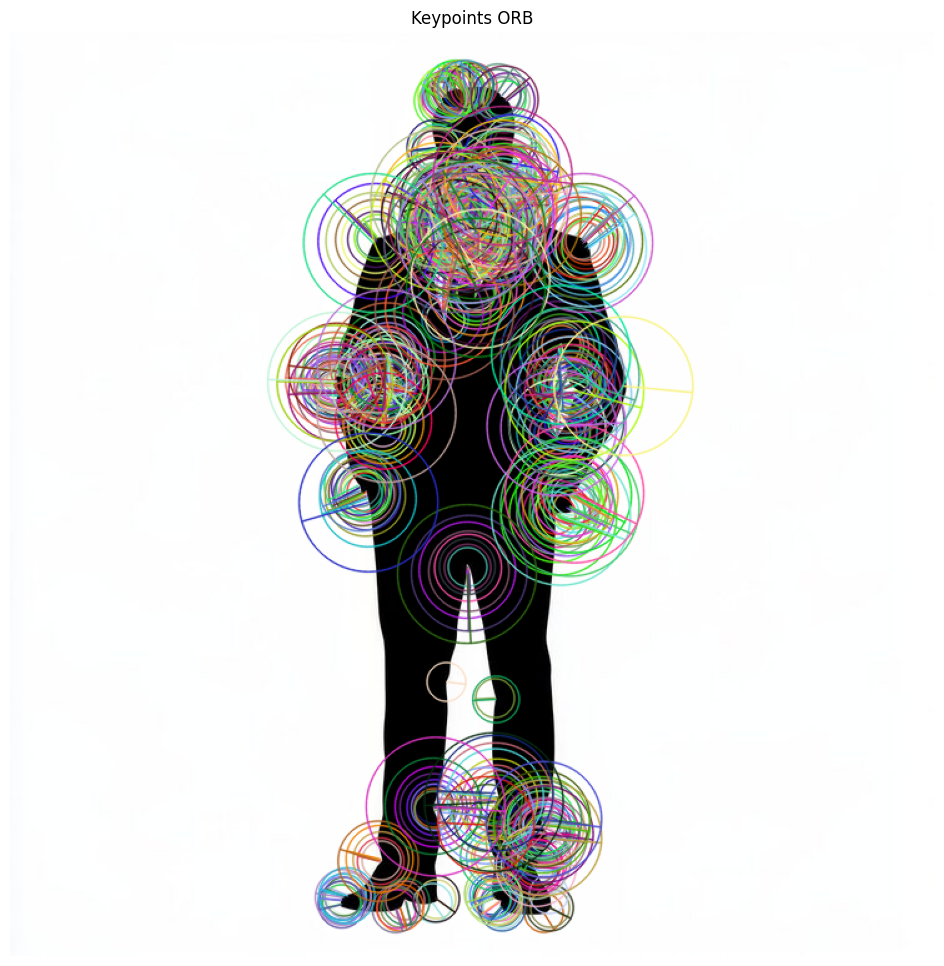

In [41]:

# ============================================================
# 3. IMPLEMENTACIÓN DE ORB
# ============================================================

print("\n====================")
print("IMPLEMENTACIÓN ORB")
print("====================")

# Medición de tiempo
start_time = time.time()

# Crear detector ORB
orb = cv2.ORB_create()

# Detectar keypoints y descriptores
orb_keypoints, orb_descriptors = orb.detectAndCompute(gray, None)

# Tiempo total
orb_time = time.time() - start_time

print(f"Cantidad de keypoints ORB: {len(orb_keypoints)}")
print(f"Tiempo de ejecución: {orb_time:.4f} segundos")

# Dibujar keypoints
orb_image = cv2.drawKeypoints(
    image_rgb,
    orb_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Mostrar resultado
plt.figure(figsize=(12,12))
plt.imshow(orb_image)
plt.title("Keypoints ORB")
plt.axis("off")
plt.show()


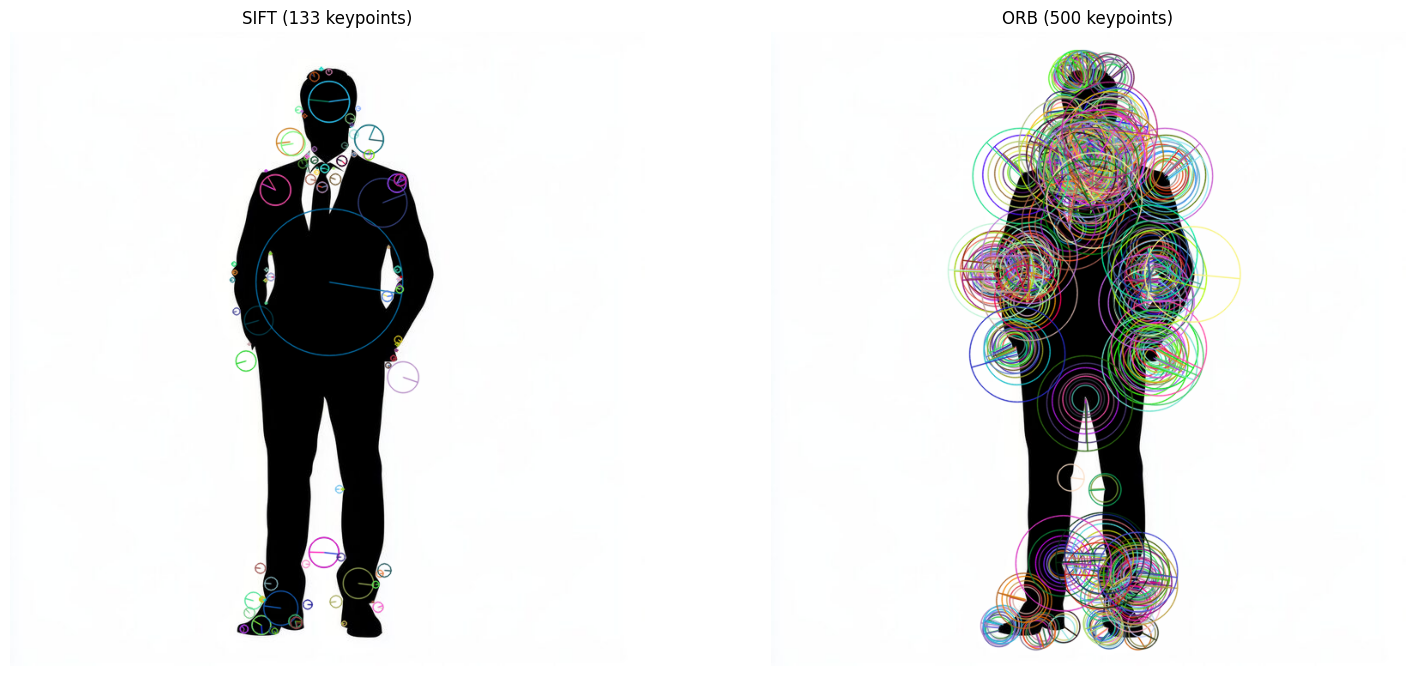

In [42]:

# ============================================================
# 4. COMPARACIÓN VISUAL SIFT VS ORB
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(18,10))

ax[0].imshow(sift_image)
ax[0].set_title(f"SIFT ({len(sift_keypoints)} keypoints)")
ax[0].axis("off")

ax[1].imshow(orb_image)
ax[1].set_title(f"ORB ({len(orb_keypoints)} keypoints)")
ax[1].axis("off")

plt.show()


In [43]:

# ============================================================
# 5. PRUEBAS DE ROBUSTEZ
# ============================================================

print("\n====================")
print("PRUEBAS DE ROBUSTEZ")
print("====================")

# ------------------------------------------------------------
# ROTACIÓN
# ------------------------------------------------------------

height, width = gray.shape

rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2), 45, 1)

rotated = cv2.warpAffine(gray, rotation_matrix, (width, height))

# SIFT
rot_sift_kp, _ = sift.detectAndCompute(rotated, None)

# ORB
rot_orb_kp, _ = orb.detectAndCompute(rotated, None)

print("\n--- Imagen Rotada 45° ---")
print(f"SIFT keypoints: {len(rot_sift_kp)}")
print(f"ORB keypoints: {len(rot_orb_kp)}")

# ------------------------------------------------------------
# ESCALA
# ------------------------------------------------------------

scaled = cv2.resize(gray, None, fx=0.5, fy=0.5)

scale_sift_kp, _ = sift.detectAndCompute(scaled, None)
scale_orb_kp, _ = orb.detectAndCompute(scaled, None)

print("\n--- Imagen Escalada 50% ---")
print(f"SIFT keypoints: {len(scale_sift_kp)}")
print(f"ORB keypoints: {len(scale_orb_kp)}")

# ------------------------------------------------------------
# ILUMINACIÓN
# ------------------------------------------------------------

bright = cv2.convertScaleAbs(gray, alpha=1.2, beta=50)

bright_sift_kp, _ = sift.detectAndCompute(bright, None)
bright_orb_kp, _ = orb.detectAndCompute(bright, None)

print("\n--- Cambio de Iluminación ---")
print(f"SIFT keypoints: {len(bright_sift_kp)}")
print(f"ORB keypoints: {len(bright_orb_kp)}")



PRUEBAS DE ROBUSTEZ

--- Imagen Rotada 45° ---
SIFT keypoints: 136
ORB keypoints: 500

--- Imagen Escalada 50% ---
SIFT keypoints: 109
ORB keypoints: 425

--- Cambio de Iluminación ---
SIFT keypoints: 142
ORB keypoints: 500


In [44]:

# ============================================================
# 6. TABLA COMPARATIVA
# ============================================================

print("\n====================")
print("TABLA COMPARATIVA")
print("====================")

print(f"""
| Característica                  | SIFT                | ORB                 |
|---------------------------------|--------------------|--------------------|
| Número de keypoints             | {len(sift_keypoints)}                 | {len(orb_keypoints)}                 |
| Tiempo de ejecución             | {sift_time:.4f} s           | {orb_time:.4f} s           |
| Robustez a rotación             | Alta               | Media-Alta         |
| Robustez a escala               | Alta               | Media              |
| Robustez a iluminación          | Alta               | Media              |
| Velocidad                       | Más lento          | Más rápido         |
| Tipo de descriptor              | Float              | Binario            |
| Uso recomendado                 | Precisión          | Tiempo real        |
""")



TABLA COMPARATIVA

| Característica                  | SIFT                | ORB                 |
|---------------------------------|--------------------|--------------------|
| Número de keypoints             | 133                 | 500                 |
| Tiempo de ejecución             | 0.0869 s           | 0.0050 s           |
| Robustez a rotación             | Alta               | Media-Alta         |
| Robustez a escala               | Alta               | Media              |
| Robustez a iluminación          | Alta               | Media              |
| Velocidad                       | Más lento          | Más rápido         |
| Tipo de descriptor              | Float              | Binario            |
| Uso recomendado                 | Precisión          | Tiempo real        |




AKAZE
Cantidad de keypoints AKAZE: 463
Tiempo de ejecución: 0.0494 segundos


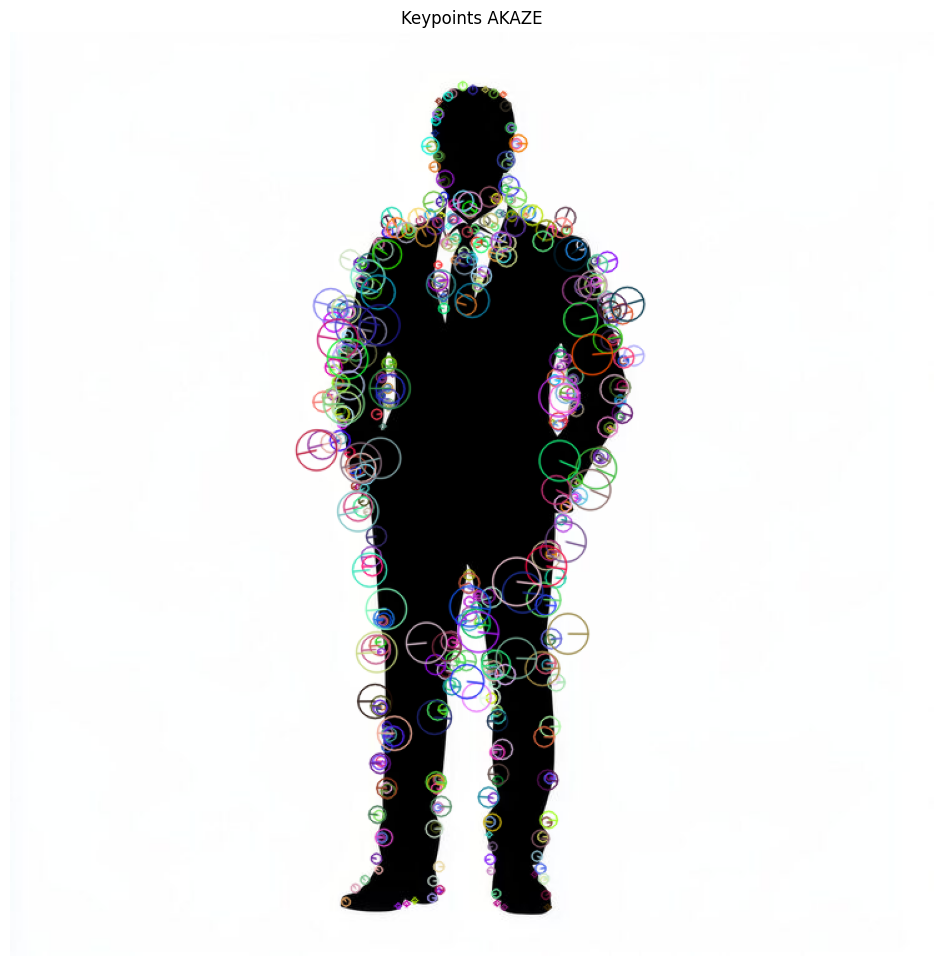

In [45]:

# ============================================================
# 7. AKAZE
# ============================================================

print("\n====================")
print("AKAZE")
print("====================")

akaze = cv2.AKAZE_create()

start_time = time.time()

akaze_kp, akaze_desc = akaze.detectAndCompute(gray, None)

akaze_time = time.time() - start_time

print(f"Cantidad de keypoints AKAZE: {len(akaze_kp)}")
print(f"Tiempo de ejecución: {akaze_time:.4f} segundos")

akaze_image = cv2.drawKeypoints(
    image_rgb,
    akaze_kp,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12,12))
plt.imshow(akaze_image)
plt.title("Keypoints AKAZE")
plt.axis("off")
plt.show()



BRISK
Cantidad de keypoints BRISK: 355
Tiempo de ejecución: 0.0075 segundos


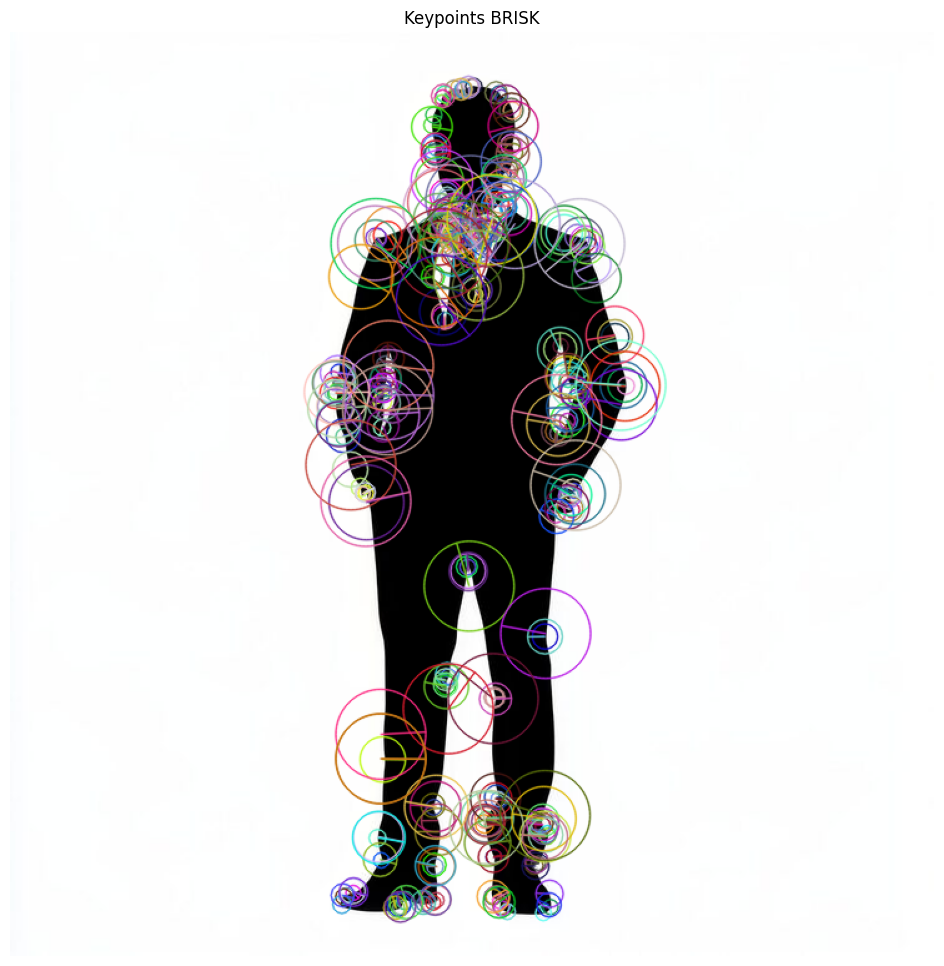

In [46]:

# ============================================================
# 8. BRISK
# ============================================================

print("\n====================")
print("BRISK")
print("====================")

brisk = cv2.BRISK_create()

start_time = time.time()

brisk_kp, brisk_desc = brisk.detectAndCompute(gray, None)

brisk_time = time.time() - start_time

print(f"Cantidad de keypoints BRISK: {len(brisk_kp)}")
print(f"Tiempo de ejecución: {brisk_time:.4f} segundos")

brisk_image = cv2.drawKeypoints(
    image_rgb,
    brisk_kp,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12,12))
plt.imshow(brisk_image)
plt.title("Keypoints BRISK")
plt.axis("off")
plt.show()